#Exp 5. Spam Email Detection:
Build a spam email filter using text
classification algorithms and perform comparative analysis. (Naïve
Bayes, Logistic Regression, Support Vector Machine, Decision Tree,
Random Forest)

#Dataset Loading and Exploration

In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
print("Ready for spam detection!")


Ready for spam detection!


#Load Dataset


In [2]:
csv_path = '/content/drive/MyDrive/AML_Lab_B19/Exp-5 Spam Email Detection/spam_email_500_samples.csv'
df = pd.read_csv(csv_path)
print(f"Loaded: {df.shape}")
print("Columns:", df.columns.tolist())
print(df.head())
print("\nLabel distribution:\n", df.iloc[:,-1].value_counts(normalize=True))


Loaded: (500, 2)
Columns: ['label', 'text']
  label                                               text
0  spam  Free entry in 2 million dollar contest. Click ...
1  spam       Act now! This offer is valid for today only.
2  spam  Get cheap medicines online without prescriptio...
3   ham                        Lunch at 1 PM works for me.
4   ham                     Thank you for your assistance.

Label distribution:
 text
Get cheap medicines online without prescription. Limited offer!                0.080
Can you share the project update?                                              0.066
Your order has been shipped successfully.                                      0.062
Congratulations! You have won a $1000 gift card. Click here to claim now.      0.062
You are selected for a free vacation. Call now to confirm.                     0.060
Let me know if you need any further information.                               0.060
Looking forward to our discussion.                               

#Preprocess Text

In [3]:
# Detect text & label columns (adapt if different)
text_col = df.columns[df.columns.str.contains('text|email|message', case=False)][0]
label_col = df.columns[df.columns.str.contains('spam|class|label', case=False)][0]
print(f"Text: {text_col}, Label: {label_col}")

X = df[text_col].fillna('').astype(str).values
y_raw = df[label_col]

# Encode labels to 0/1
le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f"Encoded labels: {np.bincount(y)} (0=ham, 1=spam)")


Text: text, Label: label
Encoded labels: [250 250] (0=ham, 1=spam)


#TF-IDF Vectorization & Split

In [4]:
vectorizer = TfidfVectorizer(max_features=2000, stop_words='english', ngram_range=(1,2))
X_tfidf = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.3, stratify=y, random_state=42)
print(f"TF-IDF shape: {X_tfidf.shape}")


TF-IDF shape: (500, 152)


#Train Models

In [5]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"Trained {name}")


Trained Naive Bayes
Trained Logistic Regression
Trained SVM
Trained Decision Tree
Trained Random Forest


#Predictions & Metrics

In [6]:
metrics = {}
cms = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': classification_report(y_test, y_pred, output_dict=True)['1']['precision'],
        'Recall': classification_report(y_test, y_pred, output_dict=True)['1']['recall'],
        'F1-Score': classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'],
        'ROC-AUC': auc
    }
    cms[name] = confusion_matrix(y_test, y_pred)

    print(f"\n{name}:\n{classification_report(y_test, y_pred)}")

df_metrics = pd.DataFrame(metrics).T.round(4)
print("\nComparative Table:\n", df_metrics)



Naive Bayes:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        75
           1       1.00      1.00      1.00        75

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150


Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        75
           1       1.00      1.00      1.00        75

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150


SVM:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        75
           1       1.00      1.00      1.00        75

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.0

#Visualizations

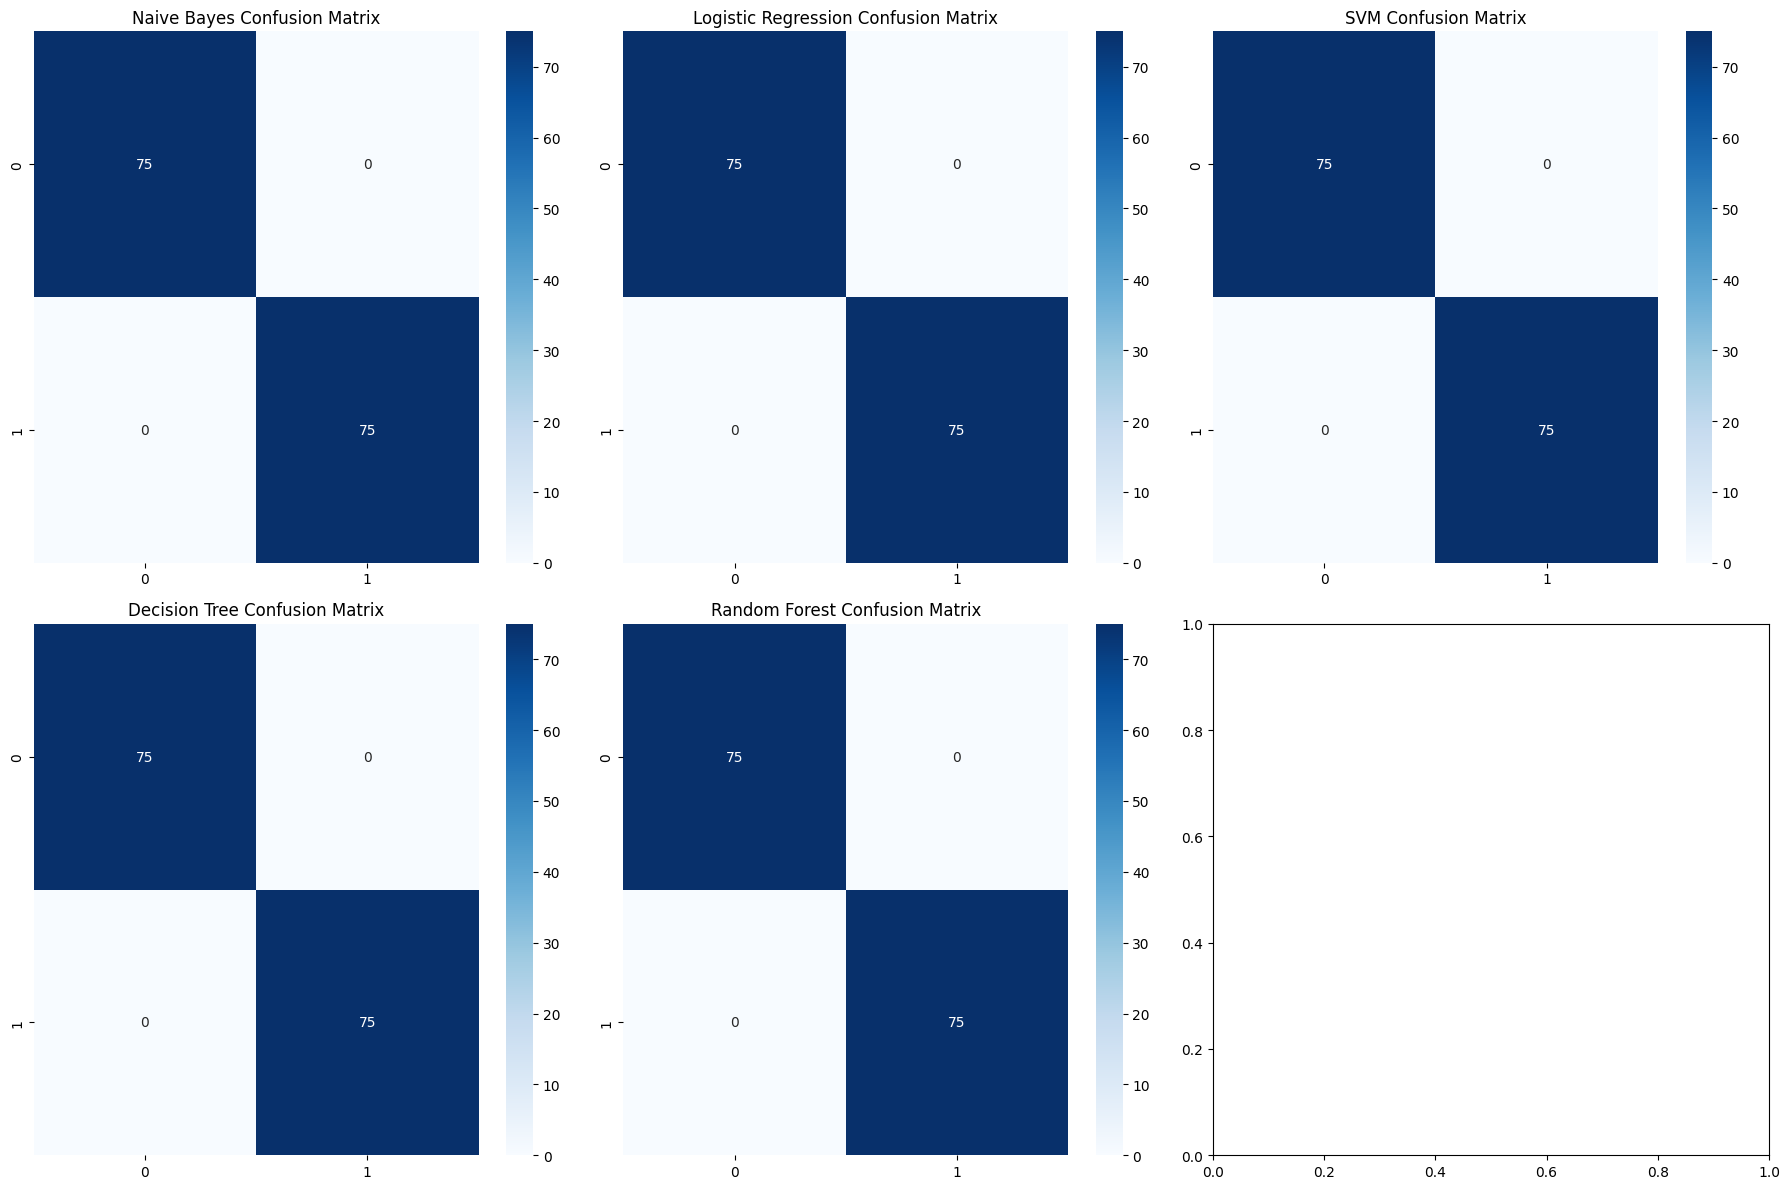

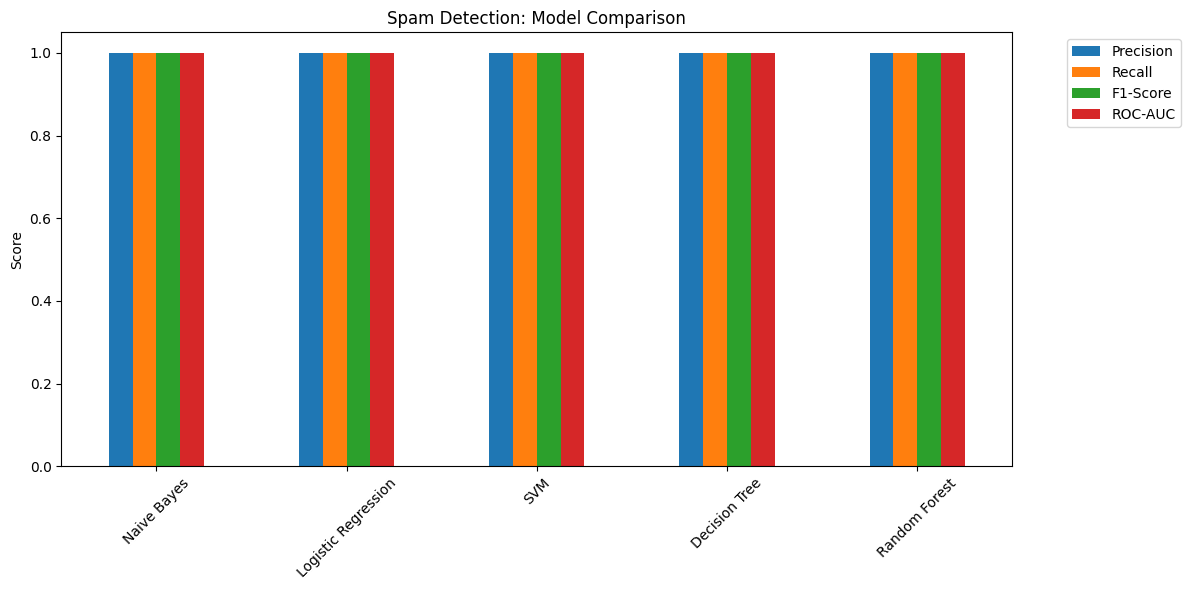

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, name in enumerate(trained_models.keys()):
    cm = cms[name]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')

plt.tight_layout()
plt.show()

# Metrics bar
df_metrics[['Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(kind='bar', figsize=(12, 6))
plt.title('Spam Detection: Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()
